In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('/Users/nithin/Downloads/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/Users/nithin/Downloads/house-prices-advanced-regression-techniques/test.csv')

print(train.shape)
print(test.shape)
train.head()

(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
null_counts = train.isnull().sum()
null_counts[null_counts > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [6]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

zero_cols = ['GarageYrBlt', 'MasVnrArea']

for col in none_cols:
    train[col] = train[col].fillna('None')
    
for col in zero_cols:
    train[col] = train[col].fillna(0)

train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

train.isnull().sum().sum()

np.int64(0)

In [7]:
train['MSSubClass'] = train['MSSubClass'].astype(str)
train['YrSold'] = train['YrSold'].astype(str)
train['MoSold'] = train['MoSold'].astype(str)

print(train['MSSubClass'].dtype)
print(train['YrSold'].dtype)
print(train['MoSold'].dtype)

object
object
object


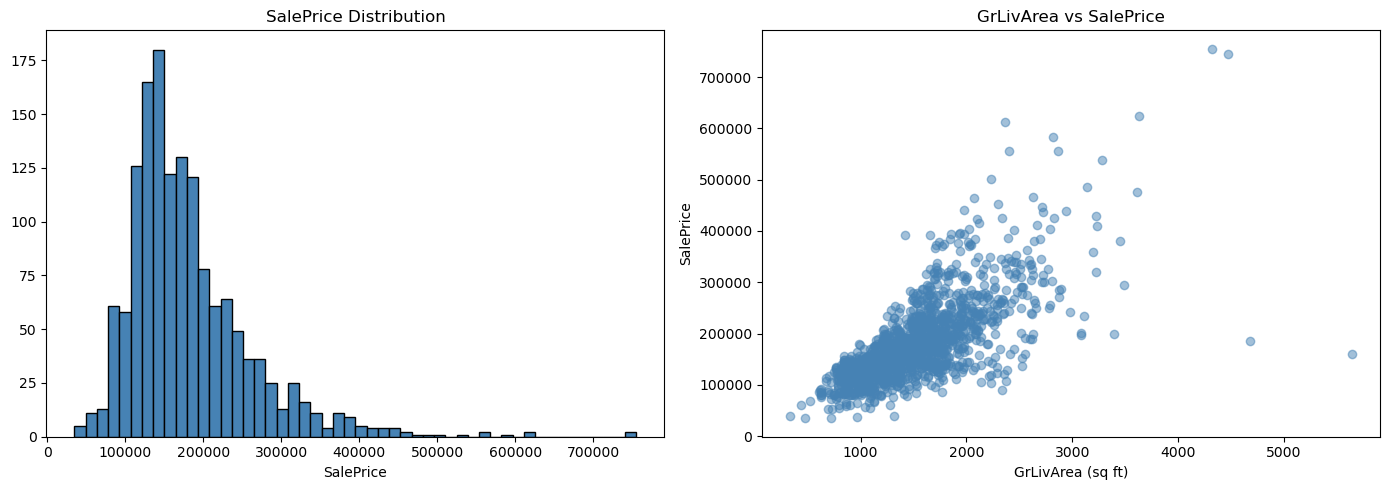

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('SalePrice')

axes[1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='steelblue')
axes[1].set_title('GrLivArea vs SalePrice')
axes[1].set_xlabel('GrLivArea (sq ft)')
axes[1].set_ylabel('SalePrice')

plt.tight_layout()
plt.show()

In [9]:
train = train[~((train['GrLivArea'] > 40000) & (train['SalePrice'] < 300000))]

print(train.shape)

(1460, 81)


In [10]:
train[train['GrLivArea'] > 4000][['GrLivArea', 'SalePrice']].sort_values('GrLivArea', ascending=False)

,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000


In [11]:
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

print(train.shape)

(1458, 81)


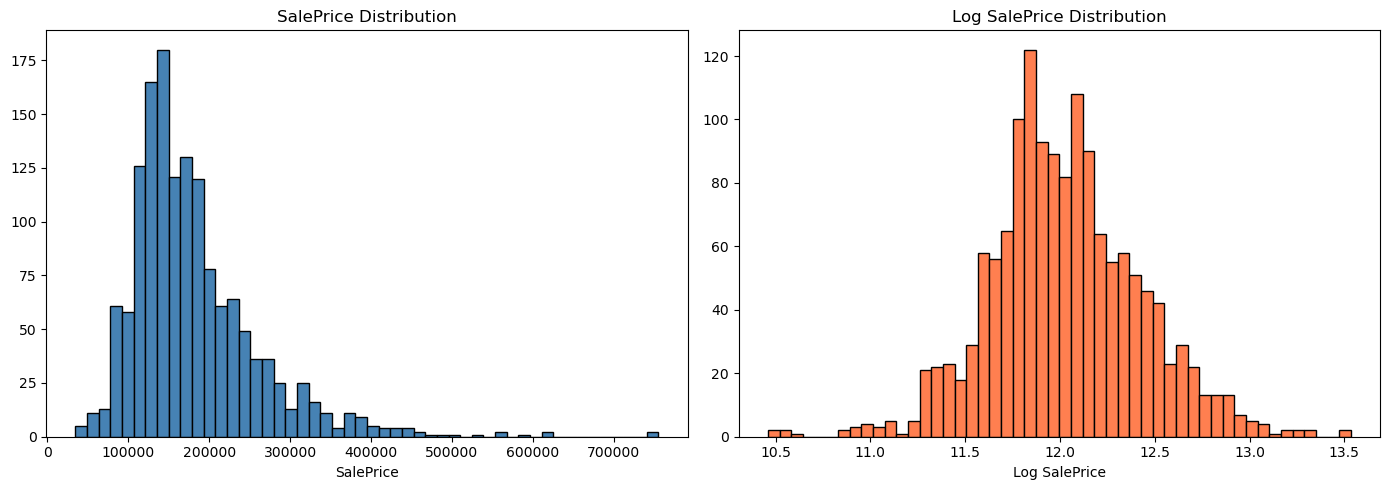

In [12]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('SalePrice Distribution')
axes[0].set_xlabel('SalePrice')

axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Log SalePrice Distribution')
axes[1].set_xlabel('Log SalePrice')

plt.tight_layout()
plt.show()

In [13]:
train['SalePrice'] = np.log1p(train['SalePrice'])

print(train['SalePrice'].describe())

count    1458.000000
mean       12.024015
std         0.399713
min        10.460271
25%        11.774720
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64


In [14]:
numeric_cols = train.select_dtypes(include=[np.number])

corr = numeric_cols.corr()['SalePrice'].sort_values(ascending=False)
print(corr.head(11))  

SalePrice       1.000000
OverallQual     0.821405
GrLivArea       0.725211
GarageCars      0.681033
GarageArea      0.656129
TotalBsmtSF     0.647563
1stFlrSF        0.620500
FullBath        0.595899
YearBuilt       0.587043
YearRemodAdd    0.565992
TotRmsAbvGrd    0.537702
Name: SalePrice, dtype: float64


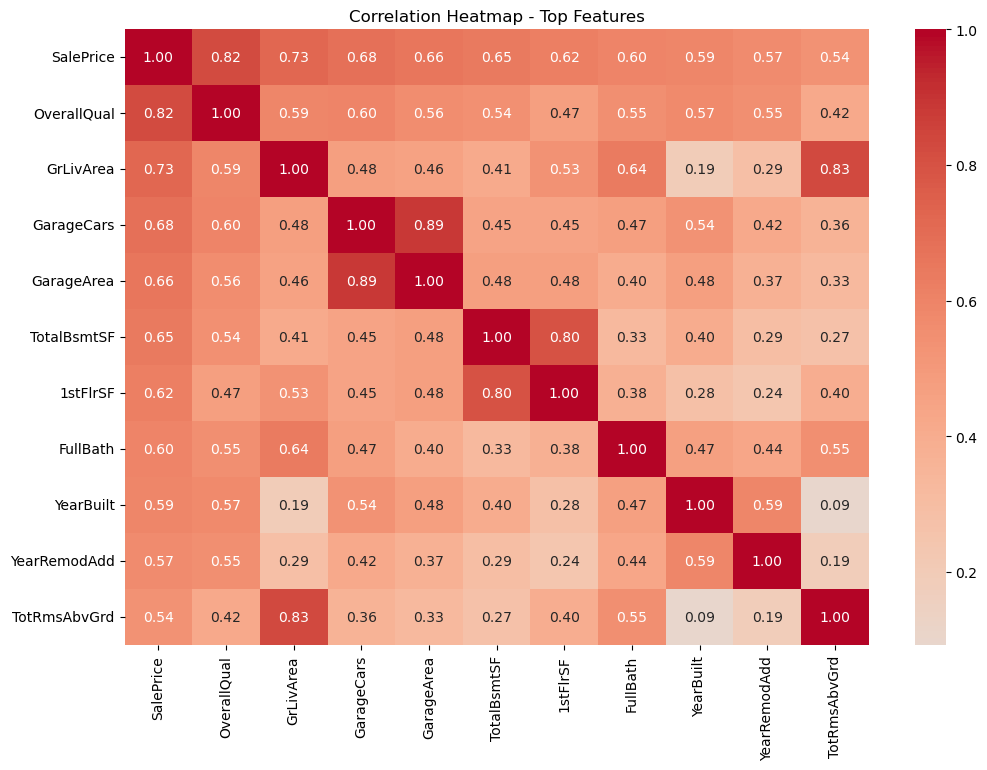

In [15]:
top_features = corr.head(11).index

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols[top_features].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap - Top Features')
plt.show()

/var/folders/31/qyglr5x93sx225sz94kjrk_c0000gn/T/ipykernel_11284/4171081557.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='coolwarm')


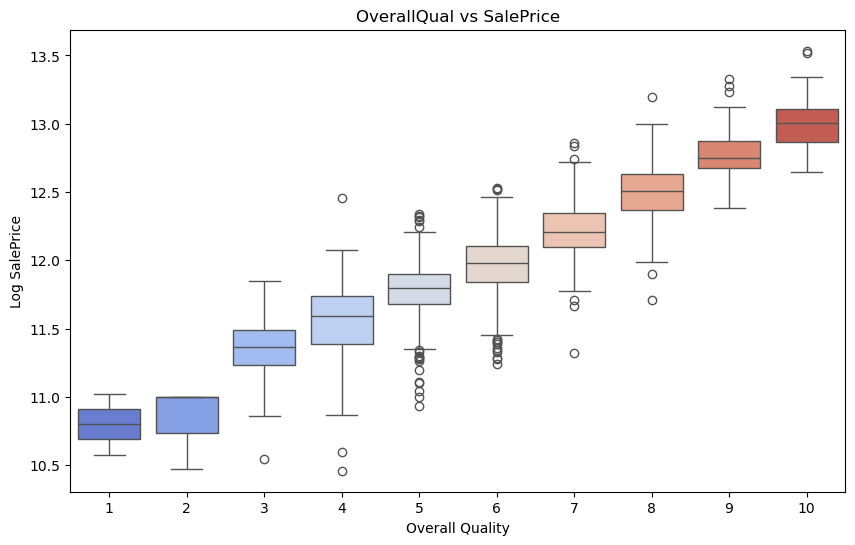

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=train, palette='coolwarm')
plt.title('OverallQual vs SalePrice')
plt.xlabel('Overall Quality')
plt.ylabel('Log SalePrice')
plt.show()

/var/folders/31/qyglr5x93sx225sz94kjrk_c0000gn/T/ipykernel_11284/1764733749.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=train, palette='coolwarm')


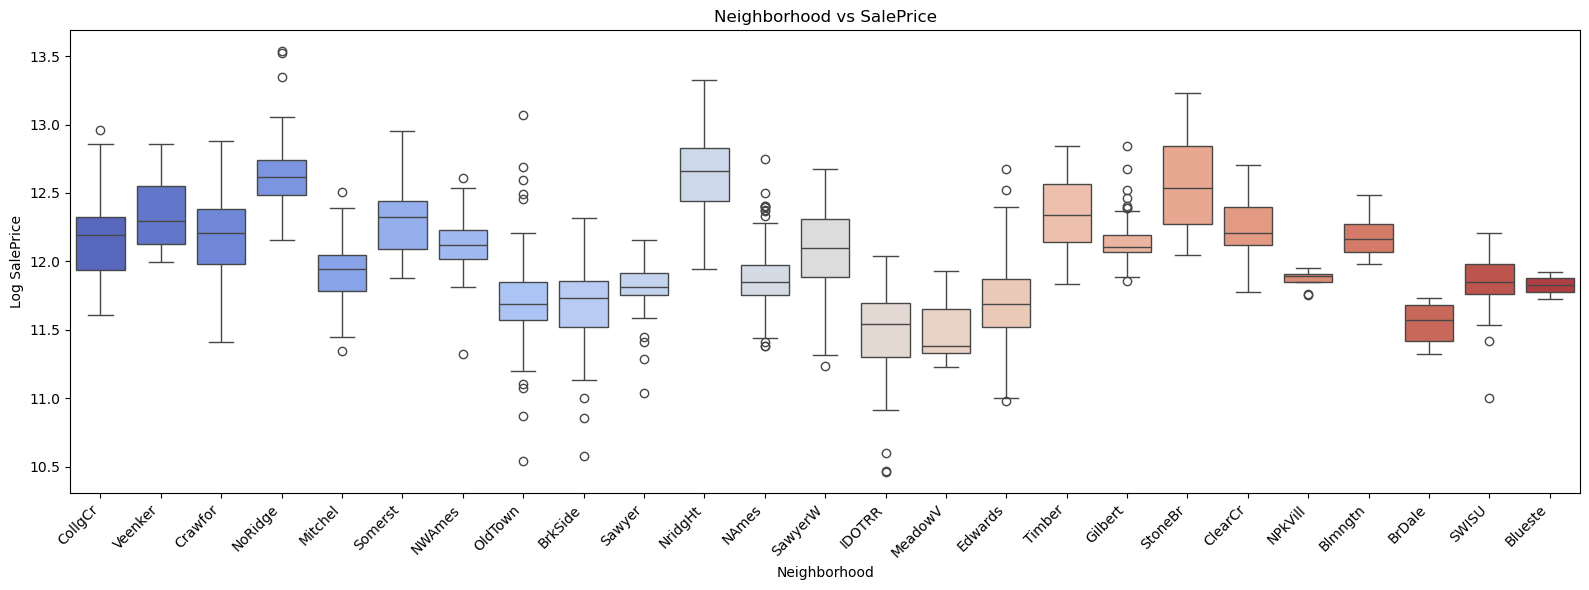

In [17]:
plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=train, palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Neighborhood vs SalePrice')
plt.xlabel('Neighborhood')
plt.ylabel('Log SalePrice')
plt.tight_layout()
plt.show()

In [18]:
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']

train['TotalBath'] = (train['FullBath'] + train['HalfBath'] * 0.5 + 
                      train['BsmtFullBath'] + train['BsmtHalfBath'] * 0.5)

train['HouseAge'] = train['YrSold'].astype(int) - train['YearBuilt']

train['Remodelled'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)

print(train[['TotalSF', 'TotalBath', 'HouseAge', 'Remodelled']].head())

   TotalSF  TotalBath  HouseAge  Remodelled
0     2566        3.5         5           0
1     2524        2.5        31           0
2     2706        3.5         7           1
3     2473        2.0        91           1
4     3343        3.5         8           0


In [19]:
drop_cols = ['GarageArea', '1stFlrSF', 'TotalBsmtSF', 
             'YearBuilt', 'YearRemodAdd', 'Id']

train = train.drop(columns=drop_cols)

print(train.shape)

(1458, 79)


In [20]:
cat_cols = train.select_dtypes(include=['object']).columns
print(f"Categorical columns: {len(cat_cols)}")

train = pd.get_dummies(train, columns=cat_cols, drop_first=True)

print(train.shape)

Categorical columns: 46
(1458, 284)


In [21]:
X = train.drop(columns=['SalePrice'])
y = train['SalePrice']

print(X.shape)
print(y.shape)

(1458, 283)
(1458,)


In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import warningsv
warnings.filterwarnings('ignore')

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_val.shape)

(1166, 283)
(292, 283)


In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Linear Regression RMSE: {rmse:.4f}")

Linear Regression RMSE: 0.1406


In [24]:
ridge = Ridge()
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Ridge RMSE: {rmse:.4f}")

Ridge RMSE: 0.1300


In [25]:
lasso = Lasso()
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Lasso RMSE: {rmse:.4f}")

Lasso RMSE: 0.1886


In [26]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Random Forest RMSE: {rmse:.4f}")

Random Forest RMSE: 0.1454


In [27]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Gradient Boosting RMSE: {rmse:.4f}")

Gradient Boosting RMSE: 0.1253


In [28]:
ridge_params = {'alpha': [0.1, 1, 5, 10, 20, 50, 100]}

ridge_grid = GridSearchCV(Ridge(), ridge_params, 
                          cv=5, 
                          scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)

print(f"Best alpha: {ridge_grid.best_params_}")
y_pred = ridge_grid.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Ridge Tuned RMSE: {rmse:.4f}")

Best alpha: {'alpha': 20}
Ridge Tuned RMSE: 0.1262


In [29]:
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1]}

lasso_grid = GridSearchCV(Lasso(), lasso_params,
                          cv=5,
                          scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train, y_train)

print(f"Best alpha: {lasso_grid.best_params_}")
y_pred = lasso_grid.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Lasso Tuned RMSE: {rmse:.4f}")

Best alpha: {'alpha': 0.001}
Lasso Tuned RMSE: 0.1235


In [44]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params,
                       cv=5,
                       scoring='neg_root_mean_squared_error')
gb_grid.fit(X_train, y_train)

print(f"Best params: {gb_grid.best_params_}")
y_pred = gb_grid.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Gradient Boosting Tuned RMSE: {rmse:.4f}")

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Gradient Boosting Tuned RMSE: 0.1267


In [45]:
# First prepare test data the same way we prepared train
test = pd.read_csv('/Users/nithin/Downloads/house-prices-advanced-regression-techniques/test.csv')

# Apply all the same cleaning steps
for col in none_cols:
    test[col] = test[col].fillna('None')
for col in zero_cols:
    test[col] = test[col].fillna(0)

test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].median())
test['Electrical'] = test['Electrical'].fillna(test['Electrical'].mode()[0])

# Fix dtypes
test['MSSubClass'] = test['MSSubClass'].astype(str)
test['YrSold'] = test['YrSold'].astype(str)
test['MoSold'] = test['MoSold'].astype(str)

print("Test nulls remaining:", test.isnull().sum().sum())

Test nulls remaining: 22


In [46]:
null_counts_test = test.isnull().sum()
null_counts_test[null_counts_test > 0].sort_values(ascending=False)

MSZoning        4
Utilities       2
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
KitchenQual     1
GarageCars      1
GarageArea      1
SaleType        1
dtype: int64

In [47]:
# Categorical - fill with mode
cat_fill = ['MSZoning', 'Utilities', 'Functional', 'Exterior1st', 
            'Exterior2nd', 'KitchenQual', 'SaleType']

for col in cat_fill:
    test[col] = test[col].fillna(test[col].mode()[0])

# Numerical - fill with median
num_fill = ['BsmtFullBath', 'BsmtHalfBath', 'BsmtFinSF1', 'BsmtFinSF2',
            'BsmtUnfSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea']

for col in num_fill:
    test[col] = test[col].fillna(test[col].median())

print("Test nulls remaining:", test.isnull().sum().sum())

Test nulls remaining: 0


In [48]:
# New features
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
test['TotalBath'] = (test['FullBath'] + test['HalfBath'] * 0.5 + 
                     test['BsmtFullBath'] + test['BsmtHalfBath'] * 0.5)
test['HouseAge'] = test['YrSold'].astype(int) - test['YearBuilt']
test['Remodelled'] = (test['YearRemodAdd'] != test['YearBuilt']).astype(int)

# Drop same columns
test = test.drop(columns=['GarageArea', '1stFlrSF', 'TotalBsmtSF', 
                           'YearBuilt', 'YearRemodAdd', 'Id'])

# One hot encode
cat_cols_test = test.select_dtypes(include=['object']).columns
test = pd.get_dummies(test, columns=cat_cols_test, drop_first=True)

print(test.shape)

(1459, 267)


In [49]:
# Align test columns to match train
X_test = test.reindex(columns=X.columns, fill_value=0)

print(X_test.shape)

(1459, 283)


In [50]:
# Predict using best model (Tuned Lasso)
predictions_log = lasso_grid.predict(X_test)

# Convert back from log scale to actual prices
predictions = np.expm1(predictions_log)

print(predictions[:5])
print(f"Min price: ${predictions.min():,.0f}")
print(f"Max price: ${predictions.max():,.0f}")
print(f"Mean price: ${predictions.mean():,.0f}")

[112366.46847298 146557.88395961 178405.54958628 201599.82748125
 191747.62395422]
Min price: $52,877
Max price: $1,945,919
Mean price: $179,277


In [51]:
submission = pd.read_csv('/Users/nithin/Downloads/house-prices-advanced-regression-techniques/test.csv')[['Id']]
submission['SalePrice'] = predictions

submission.to_csv('submission.csv', index=False)
print(submission.head())
print(submission.shape)

     Id      SalePrice
0  1461  112366.468473
1  1462  146557.883960
2  1463  178405.549586
3  1464  201599.827481
4  1465  191747.623954
(1459, 2)


In [52]:
submission = pd.read_csv('/Users/nithin/Downloads/house-prices-advanced-regression-techniques/test.csv')[['Id']]
submission['SalePrice'] = predictions
submission.to_csv('submission.csv', index=False)
print("Done")

Done


In [53]:
# Read it back and check
check = pd.read_csv('submission.csv')
print(check.head())
print(check.shape)
print(check.columns.tolist())


     Id      SalePrice
0  1461  112366.468473
1  1462  146557.883960
2  1463  178405.549586
3  1464  201599.827481
4  1465  191747.623954
(1459, 2)
['Id', 'SalePrice']


In [1]:
with open('/Users/nithin/Downloads/house_prices_submission.csv', 'r') as f:
    print(repr(f.read(200)))

'Id,SalePrice\n1461,112366.4684729778\n1462,146557.88395961394\n1463,178405.54958627996\n1464,201599.8274812453\n1465,191747.6239542236\n1466,174956.73566370996\n1467,190864.5459227922\n1468,166444.46861174842'
